# Task 1: Linear Discriminant Analysis


In [1]:
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from sklearn.metrics import confusion_matrix, classification_report, precision_score

def plot_digits(data):
    # Function to visualize the digits from data
    fig, ax = plt.subplots(10, 10, figsize=(8, 8),
                           subplot_kw=dict(xticks=[], yticks=[]))
    fig.subplots_adjust(hspace=0.05, wspace=0.05)
    for i, axi in enumerate(ax.flat):
        im = axi.imshow(data[i].reshape(8, 8), cmap='binary')
        im.set_clim(0, 16)

We load digits datasets. It contains 1797 images, each (64,) shape (8x8).

In [2]:
digits = load_digits()
print(f"Data shape : {digits.data.shape}")
print(f"Target shape : {digits.target.shape}")

Data shape : (1797, 64)
Target shape : (1797,)


### 1.1 Visualize a few digit images from the dataset.

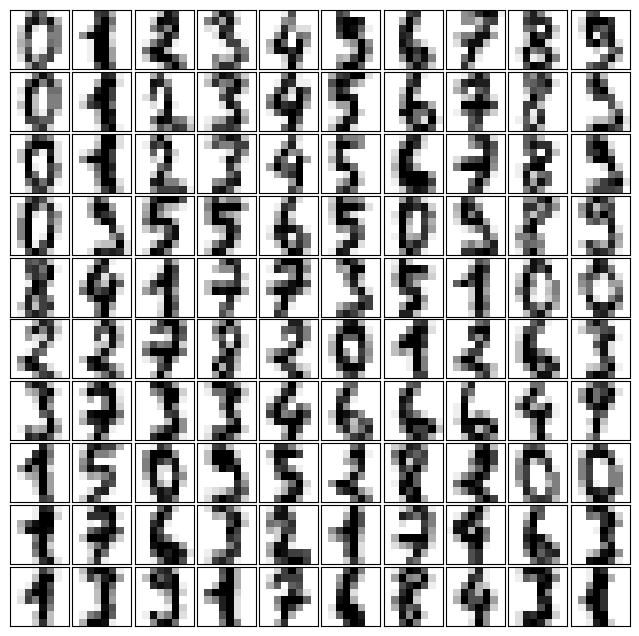

In [3]:
# Write your code here
plot_digits(digits.data)

### 1.2 Split dataset into train and test datasets. Apply PCA.



In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    digits.data, digits.target
    )
classes = [0, 1,2,3,4,5,6,7,8,9]


# Fit scaler and PCA on training data only
scaler = StandardScaler()
X_train_scaled = scaler.fit(X_train).transform(X_train)

pca = PCA(n_components=50)
X_train_pca = pca.fit(X_train).transform(X_train)

# Apply the same transformations to test data (very important!)
X_test_scaled = scaler.transform(X_test)
X_test_pca = pca.transform(X_test)

X_train, X_test = X_train_pca, X_test_pca
n_features = X_train.shape[-1]


### 1.3 Compute the mean vector of each class.

Given `X_train` with shape `(n_samples, n_features)` and corresponding class labels `y_train`,  
we can compute the mean feature vector for each class as follows:


In [5]:
g = np.zeros((len(classes), n_features))
for cur_class in classes:
  g[cur_class] = np.mean(X_train[y_train == cur_class], axis=0)

**Visualizing Class Centers**

Visualizing the class mean vectors (`g`) and training samples  
along the first two principal coordinates:


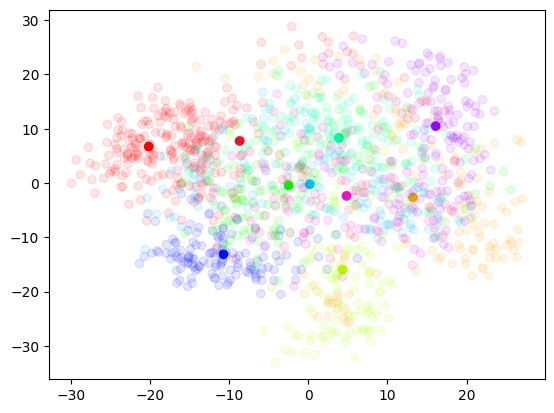

In [6]:
feature_1 = 1
feature_2 = 2
plt.scatter(g[:,feature_1], g[:,feature_2], c=classes,cmap="hsv")
plt.scatter(X_train[:,feature_1], X_train[:,feature_2], c=y_train, alpha=0.1,cmap="hsv")

### 1.4 Formulate and compute the intra-class scatter matrix $S_w$

The matrix $S_w$ measures how spread out the samples are inside each class.

Mathematical formulation:

$$S_w = \sum_k \frac{1}{N_k}A_kA_k^T$$

with $A_k$ the data of class $k$ centered around the mean of the class $k$.

$S_w$ is basically the sum of all covariance $S_k$ of each class $k$.

In [7]:
def compute_A_k(k):
  # Center data of class k around its mean vector g[k]
  cur_class = classes[k]
  A_k = (X_train[y_train == cur_class] - g[cur_class]).T
  assert A_k.shape[0] == n_features
  return A_k

def compute_S_w():
  # Compute S_w: measures how spread out samples are inside each class
  # For each class:
  #   - Center samples (A_k)
  #   - Compute variation (A_k @ A_k.T)
  #   - Normalize by n_k and sum across classes
  S_w = 0
  for k in range(len(classes)):
    cur_class = classes[k]
    A_k = compute_A_k(k)
    n_k = X_train[y_train == cur_class].shape[0]
    S_w += 1 / n_k * A_k @ A_k.T
  assert S_w.shape == (n_features, n_features)
  return S_w

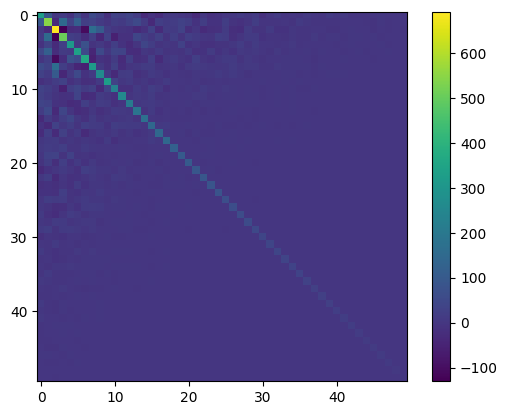

In [8]:
S_w = compute_S_w()
plt.imshow(S_w)
plt.colorbar()

### 1.5 Formulate and compute the inter-class scatter matrix $S_b$

The matrix $S_b$ measures how far apart the **class means** are from the **overall mean**.
It captures the **separation between classes**. Larger $S_b$ means better class separability.

Mathematical formulation:

$$S_b = \frac{1}{M}B B^T$$
with:

- $M$ the number of classes
- $B = \begin{bmatrix} \mu_1 - \mu & \cdots & \mu_M - \mu\end{bmatrix}$ the matrix of means of each class centered around $0$
- $\mu_i$ the mean of the class $i$
- $\mu$ the global mean.

$S_b$ is basically the covariance of the means of each class centered around $0$.

In [9]:
def compute_B():
  # Center class mean vectors around the global mean
  # Returns B with shape (n_features, n_classes)
  g_mean = np.mean(X_train)
  B = (g - g_mean).T
  assert B.shape == (n_features, len(classes))
  return B

def compute_S_b():
  # Compute S_b: measures how far class means are from the global mean
  # Uses B to calculate between-class spread
  B = compute_B()
  S_b = 1 / len(classes) * B @ B.T
  assert S_b.shape == (n_features, n_features)
  return S_b

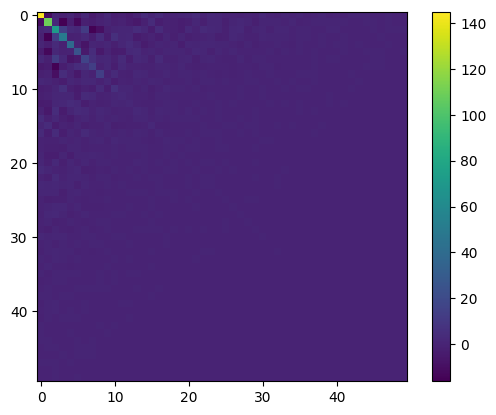

In [10]:
S_b = compute_S_b()
plt.imshow(S_b)
plt.colorbar()

### 1.6 Set up the Fisher Criterion as a generalized eigenvalue problem

To find the optimal projection directions $ a $,  we solve the **Fisher criterion**, expressed as a generalized eigenvalue problem:

$$
S_b\, a = \lambda\, S_w\, a
$$

where:
- $S_b$: between-class scatter matrix  
- $S_w$: within-class scatter matrix  
- $\lambda$: eigenvalue (class separability along direction $a$)  
- $a$: eigenvector (LDA projection direction)


In [11]:
matrix = np.linalg.inv(S_w) @ S_b       # Form matrix S_w^{-1} * S_b  (convert to standard eigenvalue problem)
w, a = np.linalg.eig(matrix)            # Compute eigenvalues (w) and eigenvectors (a)

### 1.7 Sort the eigenvalues/eigenvectors and compare with the results shown in the lecture.

c:\Users\Sinbad\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\Sinbad\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


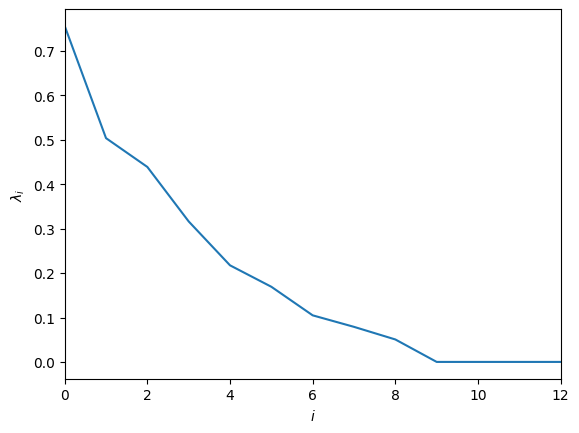

In [12]:
idx = np.argsort(w)[::-1]
w = w[idx]
a = a[:, idx]
plt.plot(w)
plt.ylabel(r"$\lambda_i$")
plt.xlabel(r"$i$")
plt.xlim(0,12)
plt.show()

### 1.8 Apply the LDA directions to the test data and visualize in 2D.

Visualize test samples in the **2 most discriminative** LDA directions (those with the largest eigenvalues $\lambda$).

In [29]:
idx = np.argsort(w.real)[::-1]          # order eigenpairs by λ (desc)
a_main = a[:, idx[:2]]# Write your code here         # top-2 LDA directions
X_transformed = X_test @ a_main # project test data

c:\Users\Sinbad\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\Sinbad\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


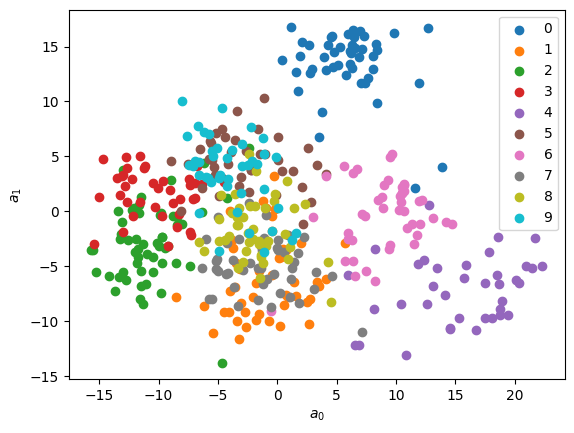

In [30]:
for k, class_ in enumerate(classes):
  plt.scatter(X_transformed[y_test==class_][:, 0], X_transformed[y_test==class_][:, 1], label=class_)
plt.xlabel(r"$a_0$")
plt.ylabel(r"$a_1$")
plt.legend()
plt.show()

### 1.9 Why do we maximize the ratio of between-class to within-class scatter in LDA?

We maximize the ratio of between-class to within-class scatter in LDA because we want to find a projection that discriminate the most our dataset.

This projection is given by the projection that maximise the distance between mean of each class to avoid overlaps on classes.
This is called the between-class or inter-class criteria.

However, if we just consider the distance between means, we can have overlap on classes, even if the means are far away if the variances of classes are high.
So in the same time, we try to minimise variance of theses classes to avoid overlap, and this is called the within-class or intra-class criteria.

So we want to minimise the variance of each class (within-class) and we want to maximise distance between means (between-class).

As we want to minimise variance of each class, we try to maximise inverse of variance.

That's why we want to maximise the ratio of the distance between means to the variance of each class, so the ratio of between-class to within-class.

### 1.10 For 𝑀 classes, how many discriminant directions can LDA provide at most?

For instance, if we have only 1 class, we don't need any discriminant to determine that a new element will be labeled in this class, because it's the unique class.
So we have $1 - 1 = 0$ discriminant needed.

If we have 2 classes, to discriminate the two classes, the projection of the classes on a single line are enough to discriminate the two classes.
In other term, $2 - 1 = 1$ discriminant direction is needed.

That's why in the same way, for $M$ classes, LDA can provide $M - 1$ discriminant directions at most to properly discriminate each class.

### 1.11 What is the key difference between PCA and LDA in terms of the criterion they optimize?

PCA try to maximize the variance of data on each dimension whereas LDA try to maximize the mean distance between each class and to minimize variance of each class.
So in one case, the goal is to reduce dimensionality by projecting data because the variance measure the quanity of information.
And in other case, the goal is to discriminate the most the clusters by projecting the data.

To summarize, PCA try to maximize global variance whereas LDA try to maximise distance between means and to minimise variance of each class to discrimitate the most the clusters.

# Task 2: k-means

### 2.1 Create a subset of MNIST which consists of 2000 randomly sampled instances of “3”s and “7”s.

In [15]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

images, images_labels = fetch_openml('mnist_784', return_X_y=True, as_frame=False, parser='auto')
train_images, test_images, train_labels, test_labels = train_test_split(images, images_labels, random_state=42)

def select_with_label(images, labels, desired_labels):
  mask = np.isin(labels, desired_labels)
  return images[mask], labels[mask]

In [16]:
data3, labels3 = select_with_label(images, images_labels, ['3'])
data7, labels7 = select_with_label(images, images_labels, ['7'])
index3 = np.random.choice(np.arange(data3.shape[0]).astype(int), size=1000)
index7 = np.random.choice(np.arange(data7.shape[0]).astype(int), size=1000)
data, labels = np.concatenate([data3[index3], data7[index7]]), np.concatenate([labels3[index3], labels7[index7]])
# data, labels = select_with_label(images, labels, ['3', '7'])

### 2.2 Implement k-means from scratch.

Implement k-means from scratch (do not use 'sklearn') with random initialization of the clusters. Perform the algorithm with $K = 2, 3, \ldots, 10$. Compute objective function $L$ defined earlier for each $K$. Plot $L$ varying with $K$. **Describe** the effect of $K$ over $L$.

*Note: This might take about 2-3 minutes to run an optimized version of K-means for large K.*


In [ ]:
import numpy as np

class KMeans:
    def __init__(self, n_clusters, init="random", max_iter=300, seed=None):
        self.n_clusters = int(n_clusters)
        self.init = init
        self.max_iter = int(max_iter)
        self.tol = 1e-4  # stop when centroid movement < tol
        self.centroids = None
        self.seed = seed

    def _init_centroids(self, X):
        n_samples = X.shape[0]
        rng = np.random.default_rng(seed=self.seed)
        if self.init == "random":
            idx = rng.choice(n_samples, size=self.n_clusters, replace=False,)
            return X[idx].copy()

        if self.init == "kmeans++":
            idx = []
            idx.append(np.random.choice(np.arange(X.shape[0])))
            for i in range(1, self.n_clusters):
                distance = np.sum([np.linalg.norm(X - mu, axis=1) for mu in X[np.array(idx)]], axis=0)
                probabilities = distance / np.sum(distance)
                idx.append(np.random.choice(np.arange(X.shape[0]), p=probabilities))

            idx = np.array(idx)
            return X[idx].copy()

        raise ValueError("init must be 'random' or 'kmeans++'")

    def fit(self, X):
        # initialize centroids randomly
        self.centroids = self._init_centroids(X)
        # this function should update self.centroids coordinates
        # for given X
        moves = np.full(self.centroids.shape[1], np.inf)
        while np.max(moves) > self.tol:
            index = self.predict(X)
            classes = np.zeros((X.shape[0], len(self.centroids)))
            classes[np.arange(classes.shape[0]), index] = 1
            old_centroids = self.centroids.copy()
            self.centroids = np.array([np.mean(X[classes[:, i] == 1], axis=0) for i in range(classes.shape[1])])
            moves = np.linalg.norm(self.centroids - old_centroids, axis=1)
        self.labels_ = self.predict(X)

    def predict(self, X):
        # this function for each X returns the cluster
        # it belongs to
        distances = np.array([np.linalg.norm(X - mu, axis=1) for mu in self.centroids])
        return np.argmin(distances, axis=0)

    def fit_predict(self, X, y=None):
        self.fit(X)
        return self.labels_

100%|██████████| 9/9 [00:11<00:00,  1.23s/it]


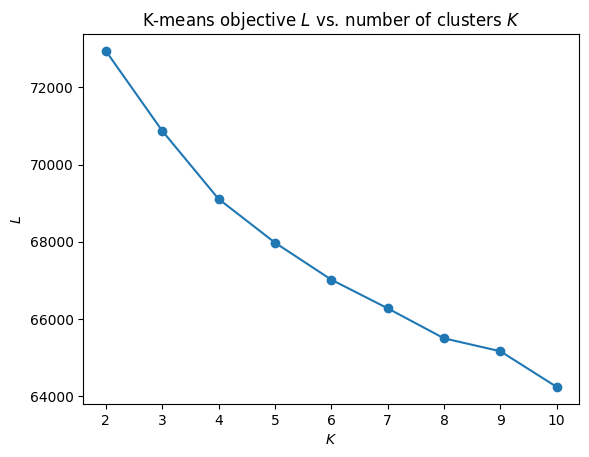

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import tqdm

Ks = range(2, 11)
L_values = []

for K in tqdm.tqdm(Ks):
    model = KMeans(n_clusters=K, init="random", max_iter=300)
    model.fit(data)

    # compute the objective function L
    labels = model.labels_
    centroids = model.centroids
    L = np.linalg.norm(data - centroids[labels])
    L_values.append(L)

plt.plot(Ks, L_values, marker="o")
plt.xlabel("$K$")
plt.ylabel("$L$")
plt.title("K-means objective $L$ vs. number of clusters $K$")
plt.show()


We can see here that when $K$ increase, the objective function $L$ decrease.
It means that the distance of each point to the nearest cluster mean decrease, so data are more concentrated around cluster means.
So it allows more precision to right discriminate data.

If we look at the shape of the curve, we can see that $L$ decrease less and less when $K$ increase.
It means that at some point, adding means to the K-means algorithm will not be benefit for the method.
In fact, a too big number of clusters may cause an overfiting of the method to the given set of data, which will decrease the accuracy of the method on new data.

### 2.3 k++ initialization

Implement k++ assignment explained in the lecture. Compare the objective function values of several runs with the random and k++ initialization for $K=2$.

In [19]:
from joblib import Parallel, delayed

# Write your code here
# Use np.random.choice with p=distance^2
model = KMeans(n_clusters=3, init="kmeans++", max_iter=300)
model.fit(data)

L1_values = []
L2_values = []

def kmean_parallelized() -> tuple:
    model1 = KMeans(n_clusters=2, init="random", max_iter=300)
    model1.fit(data)
    # compute the objective function L
    labels1 = model1.labels_
    centroids1 = model1.centroids
    L1 = np.linalg.norm(data - centroids1[labels1])

    model2 = KMeans(n_clusters=2, init="kmeans++", max_iter=300)
    model2.fit(data)
    # compute the objective function L
    labels2 = model2.labels_
    centroids2 = model2.centroids
    L2 = np.linalg.norm(data - centroids2[labels2])
    return L1, L2

results = Parallel(n_jobs=-1, verbose=10)(delayed(kmean_parallelized)() for _ in range(100))

for result in results:
    L1_values.append(result[0])
    L2_values.append(result[1])

print(f'K-Means with random initialization, objective function mean value:      {np.mean(L1_values)}')
print(f'K-Means with kmeans++ initialization, objective function mean value:    {np.mean(L1_values)}')

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    3.0s
[Parallel(n_jobs=-1)]: Done  21 tasks      | elapsed:    3.3s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    5.8s
[Parallel(n_jobs=-1)]: Done  48 out of 100 | elapsed:    6.4s remaining:    7.0s
[Parallel(n_jobs=-1)]: Done  59 out of 100 | elapsed:    7.6s remaining:    5.2s
[Parallel(n_jobs=-1)]: Done  70 out of 100 | elapsed:    8.8s remaining:    3.7s
[Parallel(n_jobs=-1)]: Done  81 out of 100 | elapsed:    9.4s remaining:    2.1s
[Parallel(n_jobs=-1)]: Done  92 out of 100 | elapsed:    9.9s remaining:    0.8s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   10.0s finished


K-Means with random initialization, objective function mean value:      72942.56158804585
K-Means with kmeans++ initialization, objective function mean value:    72942.56158804585


We can see that for this given problem, the k-means++ initialization don't bring any enhancement because the mean fitness cost is exactly the same between random and kmeans++ initialization.
In fact, kmeans++ can give better results if we run only a few time both methods, but if we run several times the method, they are the same.
So an alternative to kmeans++ implementation could be to execute several times the algorithm with the random initialization.
However, in some case where the computation of the method is costly, the kmeans++ implementation can be prefered because it help the method to go on the right direction, as shown on graphs below in next point because with the kmeans++ the points are closer to the cluster mean allowing better accuracy.

### (extra) Artificial example for K-means++

If you want to **see the difference** between random and k-means++ initialization more clearly, you can run this *artificial example*.

To make your results **reproducible**, update your `KMeans` class so that it accepts a `seed` argument and uses it in the random number generator:

```python
rng = np.random.default_rng(self.seed)
```

You might need to play with seed parameter to get different results for k-means++ and random initializations.


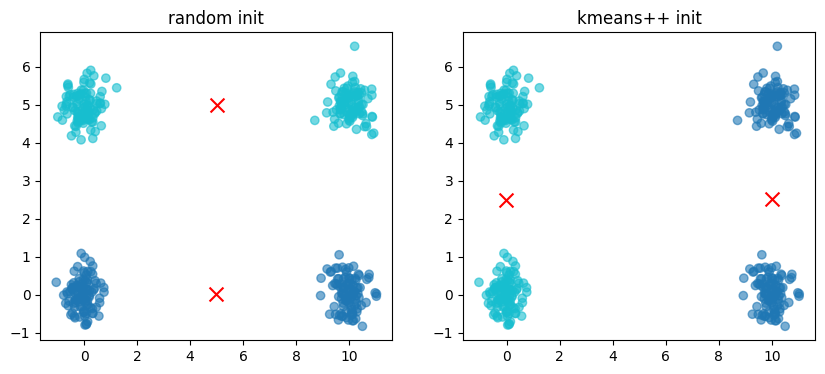

Random init: mean L = nan, std = nan
K-means++ init: mean L = nan, std = nan


c:\Users\Sinbad\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Sinbad\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


In [20]:
# --- Generate 4 distinct blobs in 2D ---
np.random.seed(42)
centers = np.array([[0, 0], [10, 5], [0, 5], [10, 0]])
X_synth = np.vstack([
    np.random.randn(100, 2) * 0.4 + center for center in centers
])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, init in zip(axes, ["random", "kmeans++"]):
    model = KMeans(n_clusters=2, init=init, max_iter=100, seed=47)
    model.fit(X_synth)
    labels = model.labels_
    ax.scatter(X_synth[:, 0], X_synth[:, 1], c=labels, cmap="tab10", alpha=0.6)
    ax.scatter(model.centroids[:, 0], model.centroids[:, 1], c="red", s=100, marker="x")
    ax.set_title(f"{init} init")

plt.show()

runs = 10
L_random, L_kpp = [], []

for init in ["random", "kmeans++"]:
    for _ in range(runs):
        model = KMeans(n_clusters=4, init=init, max_iter=100)
        model.fit(X_synth)
        labels = model.labels_
        centroids = model.centroids
        L = np.linalg.norm(X_synth - centroids[labels])
        if init == "random":
            L_random.append(L)
        else:
            L_kpp.append(L)

# --- Compare objective values ---
print(f"Random init: mean L = {np.mean(L_random):.2f}, std = {np.std(L_random):.2f}")
print(f"K-means++ init: mean L = {np.mean(L_kpp):.2f}, std = {np.std(L_kpp):.2f}")


# Task 3: GMMs

### 3.1 GMM implementation.

Use a subset of MNIST consisting of 2000 randomly sampled instances of “3”s and “7”s from the previous task. Apply PCA to reduce dimensionality. Implement GMM model from scratch (do not use \sklearn) with random initialization of the parameters.


In [ ]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

images, images_labels = fetch_openml('mnist_784', return_X_y=True, as_frame=False, parser='auto')
train_images, test_images, train_labels, test_labels = train_test_split(images, images_labels, random_state=42)

def select_with_label(images, labels, desired_labels):
  mask = np.isin(labels, desired_labels)
  return images[mask], labels[mask]

data3, labels3 = select_with_label(images, images_labels, ['3'])
data7, labels7 = select_with_label(images, images_labels, ['7'])
index3 = np.random.choice(np.arange(data3.shape[0]).astype(int), size=1000)
index7 = np.random.choice(np.arange(data7.shape[0]).astype(int), size=1000)
data, labels = np.concatenate([data3[index3], data7[index7]]), np.concatenate([labels3[index3], labels7[index7]])

In [22]:
class GMM:
    def __init__(self, n_components, max_iter=100, tol=1e-3, reg_covar=1e-6, seed=None):
        self.n_components = int(n_components)
        self.max_iter = int(max_iter)
        self.tol = float(tol)            # stop when llh improvement < tol
        self.reg_covar = float(reg_covar)
        self.seed = seed

        # learned params
        self.pi_ = None                  # mixing weights (K,)
        self.means_ = None               # means (K, D)
        self.covariances_ = None         # covariances (K, D, D)
        self.resp_ = None                # responsibilities (N, K)
        self.n_iter_ = 0
        self.lower_bound_ = -np.inf

    def phi(self, X: np.ndarray, k: int):
        assert len(X.shape) == 2, "Function phi is only applied on a single sample !"
        # ensure the covariance matrix is invertible
        cov_reg = self.covariances_[k] + np.eye(X.shape[1]) * self.reg_covar
        # No need of 2 \pi because it's only a constant !
        const = np.sqrt(np.linalg.det(cov_reg))
        X_centered = X - self.means_[k]
        exp = 1/2 * X_centered @ np.linalg.inv(cov_reg) @ X_centered.T
        return (1 / const) * np.exp(-np.diag(exp))

    def log_likelihood(self, X) -> float:
        prob = np.zeros(X.shape[0])
        for k in range(self.n_components):
            prob += self.pi_[k] * self.phi(X, k)
        self.lower_bound_ = np.sum(np.log(prob))


    def e_step(self, X):
        self.resp_ = np.zeros((X.shape[0], self.n_components))
        for k in range(self.n_components):
            self.resp_[:, k] = self.pi_[k] * self.phi(X, k)
        resp_sum = np.sum(self.resp_, axis=1)
        resp_sum = np.where(resp_sum == 0, 1, resp_sum)
        self.resp_ /= resp_sum[:, None]
    
    def m_step(self, X):
        for k in range(self.n_components):
            self.means_[k] = np.mean(self.resp_[:, k, np.newaxis] * X, axis=0) / np.mean(self.resp_[:, k], axis=0)
            X_centered = X - self.means_[k]
            self.covariances_[k] = (X_centered.T @ (X_centered * self.resp_[:, k, np.newaxis])) / np.sum(self.resp_[:, k])
        self.pi_ = np.sum(self.resp_, axis=0) / self.n_components


    def fit_predict(self, X, y=None):
        #this function returns a cluster number to each element of X
        self.pi_ = np.ones(self.n_components) / self.n_components
        n_samples = X.shape[0]
        rng = np.random.default_rng(seed=self.seed)
        idx = rng.choice(n_samples, size=self.n_components, replace=False,)
        self.means_ = X[idx].copy()
        self.covariances_ = np.array([np.eye(X.shape[1]) for _ in range(self.n_components)])
        self.n_iter_ = 0
        counter = 1
        current_lower_bound = -np.inf
        for i in range(self.max_iter):
            self.e_step(X)
            self.m_step(X)
            self.log_likelihood(X)
            self.n_iter_ += 1
            if np.abs(self.lower_bound_ - current_lower_bound) < self.tol:
                counter += 1
                if counter == 11:
                    print(f'converged after {self.n_iter_} iterations with a maximum of {self.max_iter - 1}')
                    break
            else:
                counter = 1
            current_lower_bound = self.lower_bound_
        return np.argmax(self.resp_, axis=1)
        


Apply PCA.

In [ ]:
# Write your code here (scaling)

# Use StandardScaler to give problem of zero division to sklearn for the formula: (X - mean)/std
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# Dimension reduction
pca = PCA(n_components=10)
data_pca = pca.fit_transform(data_scaled)

In [24]:
gmm = GMM(n_components=2, max_iter=100)
predicted_labels = gmm.fit_predict(data_pca)

converged after 79 iterations with a maximum of 99


**Aligning GMM clusters with true labels**

GMM is **unsupervised**, so it only assigns points to clusters (e.g., 0 or 1). It doesn’t know which cluster corresponds to which true class (e.g., 3 or 7).

To make the results comparable with the true labels, we find which class appears most often in each cluster (the **majority class**) and use that mapping when building the confusion matrix below.


Cluster 0 → true class 7
Cluster 1 → true class 3


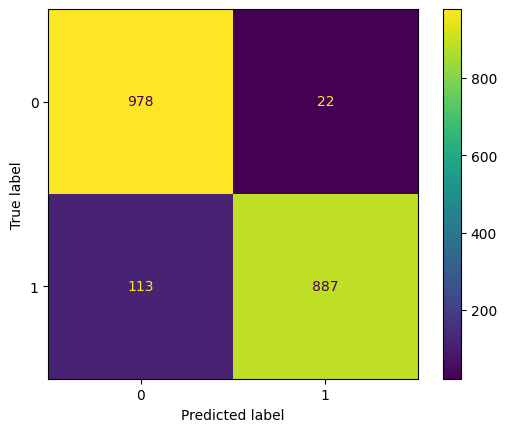

In [25]:
from collections import Counter
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def build_confusion_matrix(labels, predicted_labels, verbose=True):
  class_mapping = {}
  for k in np.unique(predicted_labels):
      maj = Counter(labels[predicted_labels == k]).most_common(1)[0][0]
      class_mapping[k] = maj
      print(f"Cluster {k} → true class {maj}")

  mapped_labels = np.vectorize(class_mapping.get)(predicted_labels)
  cm = confusion_matrix(labels, mapped_labels)
  return cm
cm = build_confusion_matrix(labels, predicted_labels)
ConfusionMatrixDisplay(cm).plot()



### 3.2 Objection function as a function of K.

Perform the algorithm with K = 2, 3, ... , 10 and plot the corresponding objection function $\mathbb{L}$. Explain what you observe.

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   9 | elapsed:    2.8s remaining:   10.2s
[Parallel(n_jobs=-1)]: Done   3 out of   9 | elapsed:   12.3s remaining:   24.8s
[Parallel(n_jobs=-1)]: Done   4 out of   9 | elapsed:   17.7s remaining:   22.1s
[Parallel(n_jobs=-1)]: Done   5 out of   9 | elapsed:   19.9s remaining:   15.9s
[Parallel(n_jobs=-1)]: Done   6 out of   9 | elapsed:   21.6s remaining:   10.8s
[Parallel(n_jobs=-1)]: Done   7 out of   9 | elapsed:   22.9s remaining:    6.5s
[Parallel(n_jobs=-1)]: Done   9 out of   9 | elapsed:   27.0s finished


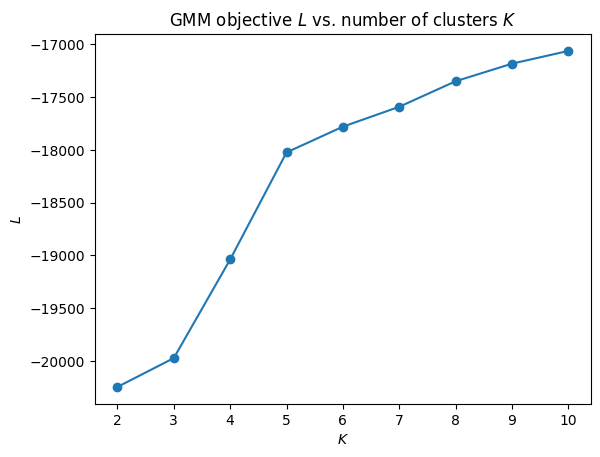

In [26]:
# Write your code here
import matplotlib.pyplot as plt
import numpy as np
import tqdm
from joblib import Parallel, delayed

Ks = range(2, 11)
L_values = []

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# Dimension reduction
pca = PCA(n_components=10)
data_pca = pca.fit_transform(data_scaled)

def gmm_parallelized(K: int) -> tuple:
    model = GMM(n_components=K, max_iter=100)
    model.fit_predict(data_pca)
    return K, model.lower_bound_

results = Parallel(n_jobs=-1, verbose=10)(delayed(gmm_parallelized)(K) for K in range(2, 11))
Ks = []
L_values = []
for result in results:
    Ks.append(result[0])
    L_values.append(result[1])


# for K in tqdm.tqdm(Ks):
#     model = GMM(n_components=K, max_iter=100)
#     
#     # compute the objective function L
#     labels = model.fit_predict(data_pca)
#     L_values.append(model.lower_bound_)

plt.plot(Ks, L_values, marker="o")
plt.xlabel("$K$")
plt.ylabel("$L$")
plt.title("GMM objective $L$ vs. number of clusters $K$")
plt.show()


We can observe that the objective function increase when the number of components increase.
In fact, it's exactly what we want because we try to maximise the objective function:

$$\text{Log-Likelihood}(\theta) = \sum_{i = 1}^N \log \left(\sum_{k = 1}^K \pi_k\phi(x_i, \Sigma_k, \mu_k)\right) =  \sum_{i = 1}^N \log \left(\sum_{k = 1}^K \mathbb{P}(x_i \in Class_k)\mathbb{P}(x_i | \Sigma_k, \mu_k)\right)$$

with

- $\mathbb{P}(x_i \in Class_k) = \pi_k$ the importance of the component $k$. In other words, it can be considered as the probability that $x_i \in Class_k$.
- $\mathbb{P}(x_i | \Sigma_k, \mu_k) = \phi(x_i, \Sigma_k, \mu_k)$ the probability given by sample $x_i$ with the function of component $k$. In our case, function $\phi$ follows a gaussian distribution.

If we look at the term $\phi(x_i, \Sigma_k, \mu_k)$, as the distribution is gaussian, it means that $\phi$ is maximal when $x_i = \mu_k$.
And it's exactly what we expect to have because we want that each $k$ component function is correctly set to match the most exactly possible our data.


### 3.3 Build confusion matrices using sklearn for kmeans and GMM for K=2 (both with PCA). Describe the results.  

converged after 28 iterations with a maximum of 99
Cluster 0 → true class 3
Cluster 1 → true class 7
Cluster 0 → true class 7
Cluster 1 → true class 3


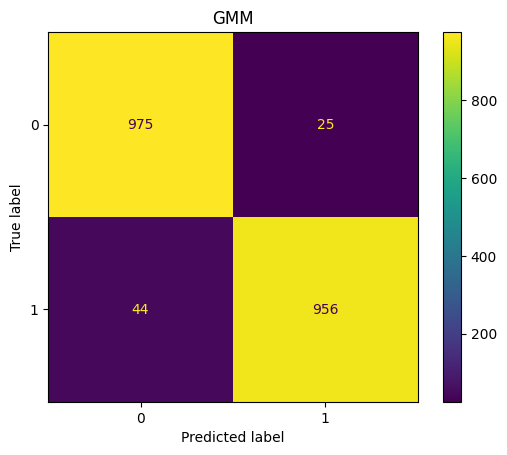

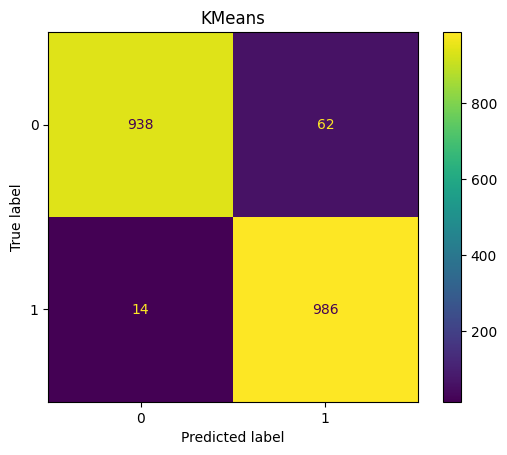

In [27]:
# Write your code here
gmm = GMM(n_components=2, max_iter=100)
predicted_labels = gmm.fit_predict(data_pca)

kmeans = KMeans(n_clusters=2, init="kmeans++", max_iter=300)
predicted_labels_kmean = kmeans.fit_predict(data_pca)



cm1 = build_confusion_matrix(labels, predicted_labels)
cm2 = build_confusion_matrix(labels, predicted_labels_kmean)
ConfusionMatrixDisplay(cm1).plot()
plt.title('GMM')
plt.show()
ConfusionMatrixDisplay(cm2).plot()
plt.title('KMeans')
plt.show()

If we look at the results, we can see that KMeans make $76$ errors on $2000$ data whereas GMM make only $69$ errors on the $2000$ data.
It means that the GMM method is more accurate than the KMeans method.

We can constate in the same time that in case of KMeans, $81\%$ of predicted errors of data are predicted $1$ instead of $0$ whereas only $63\%$ of predicted errors are $0$ instead of $1$.
In other terms, it means that the KMeans method tend to have a class which stucks up data whereas in case of GMM, errors are well distributed, so KMeans seems to separe data worse than GMM due to this 'aspiration' seen.
So for more complex problems, it could be perferable to use GMM instead of KMeans that seems to be less accurate and that seems to make worse data separation.

### 3.4 Describe the differences between kmeans and GMM (deterministic/probabilistic, parameters, functions to optimize, updates)

#### Hard-assignment VS Soft-assignment

KMeans is a hard-assignment deterministic approach. It means that a sample $x$ will belong to one unique cluster in a deterministic way: the cluster closest to the sample is the cluster assignment to this sample.

On the contrary, GMM is soft-assignment probabilistic approach: a sample can belong to each cluster with some probability.
So it allows to take care about cluster variance and importance, what the other algorithm does not take care with its hard-assignment method.



#### Parameters

In case of KMeans, only the mean of each cluster is considered, whereas in case of GMM, the mean AND the variance of each cluster is considered.
This allows a better prediction for GMM compared to KMeans that loose some important informations.

#### Functions to optimize

In case of KMeans, the function to optimize is the function of distances of each sample to its assigned cluster.
We want that this function is minimised because we want that each sample is the closest possible to its assigned cluster.

In case of GMM, the function to optimize is the likelihood, or the log-likelihood function defined as following:

$$\text{Log-Likelihood}(\theta) = \sum_{i = 1}^N \log \left(\sum_{k = 1}^K \pi_k\phi(x_i, \Sigma_k, \mu_k)\right) =  \sum_{i = 1}^N \log \left(\sum_{k = 1}^K \mathbb{P}(x_i \in Class_k)\mathbb{P}(x_i | \Sigma_k, \mu_k)\right)$$

with

- $\mathbb{P}(x_i \in Class_k) = \pi_k$ the importance of the component $k$. In other words, it can be considered as the probability that $x_i \in Class_k$.
- $\mathbb{P}(x_i | \Sigma_k, \mu_k) = \phi(x_i, \Sigma_k, \mu_k)$ the probability given by sample $x_i$ with the function of component $k$. In our case, function $\phi$ follows a gaussian distribution.

We try to find for each cluster $k$ the $\mu_k$ and $\Sigma_k$ parameters that maximise the log-likelihood.
In fact, we want that according to the weigth $\pi_k$ of the cluster $k$, each points are the closest possible to the mean according to the variance of the clusters, that maximise the function $\phi$.

So the idea betwee GMM and KMeans is the same, however we take care about the variance in case of GMM compared to KMeans.

In fact, if we decide that $\phi$ function follows only a uniform distribution, the parameters to optimise are only the means, because the uniform distribution is described only by it's mean, which would be closer to apply KMeans (but not the same because cluster importance is not considered by KMeans).

#### Updates

In case of KMeans, the updates are simple:

- The means of each cluster is recomputed after all data has been assigned to a cluster
- Then, data are reassigned to a cluster according to new means etc...

In case of GMM, it's quite complex:

- The responsibilities of each cluster according to data are computed. It describes the expectation that a given data belong to a cluster according to the global importance $\pi$ of this cluster.
- Then, according to this responsibilities of each clusters, the means and variances of each cluster are updated, and then the global importance of each cluster is updated.

So compared to KMeans, GMM has a notion of cluster importance and of cluster variance.
Because of this 'extra' computations compared to KMeans, the GMM algorithm is slower than KMeans, but more accurate thanks to this 'extra' parameters considered.